## Section 1 — Setup and Data Loading

Mini-Project: Predicting Heart Disease Using Logistic Regression (50 XP)

Dataset: Heart Disease UCI (Cleveland) — 303 patients, 14 columns (13 medical
attributes + `target`, where 1 = presence of heart disease, 0 = absence).
Loaded directly from a GitHub-hosted CSV, no manual download needed.

Steps for this mini-project:
1. Load and explore the dataset (EDA)
2. Preprocess: handle missing values, encode categoricals, scale features
3. Train/test split + Logistic Regression
4. Evaluate: accuracy, precision, recall, F1, confusion matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Section 2 — Exploratory Data Analysis (EDA)

Goal: understand the dataset's structure, check data quality, and identify
which features are most related to heart disease presence (`target`).

Steps:
1. Inspect structure, types, and summary statistics
2. Check for missing values
3. Check target class balance
4. Build a correlation heatmap to identify relationships between features
   and the target

In [2]:
print("Dataset Info:")
df.info()

print("\nBasic Statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df['target'].value_counts())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Basic Statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.

### Initial EDA — Results

- 303 patients, 14 columns, **zero missing values** — no imputation needed
- Age range 29–77 (avg ~54); ~68% male, 32% female
- Several columns (`cp`, `restecg`, `slope`, `ca`, `thal`) are categorical
  codes stored as integers, not continuous quantities — flagged for encoding
  in preprocessing
- `oldpeak` shows a wide spread (max 6.2 vs. 75th percentile of 1.6) —
  worth checking for outliers
- **Target distribution:** 165 positive (54.5%) vs. 138 negative (45.5%) —
  a reasonably balanced dataset, meaning accuracy alone should be a
  trustworthy metric (unlike a severely imbalanced case)

### Correlation Analysis

Before modeling, we check how each feature relates to `target` (heart
disease presence) and to each other. This helps identify:
- Which medical attributes are the strongest candidate predictors
- Any pairs of features that are highly correlated with each other
  (a multicollinearity risk for Logistic Regression)

A correlation heatmap visualizes all pairwise relationships at once, and we
also print the correlations with `target` specifically, sorted from
strongest positive to strongest negative.

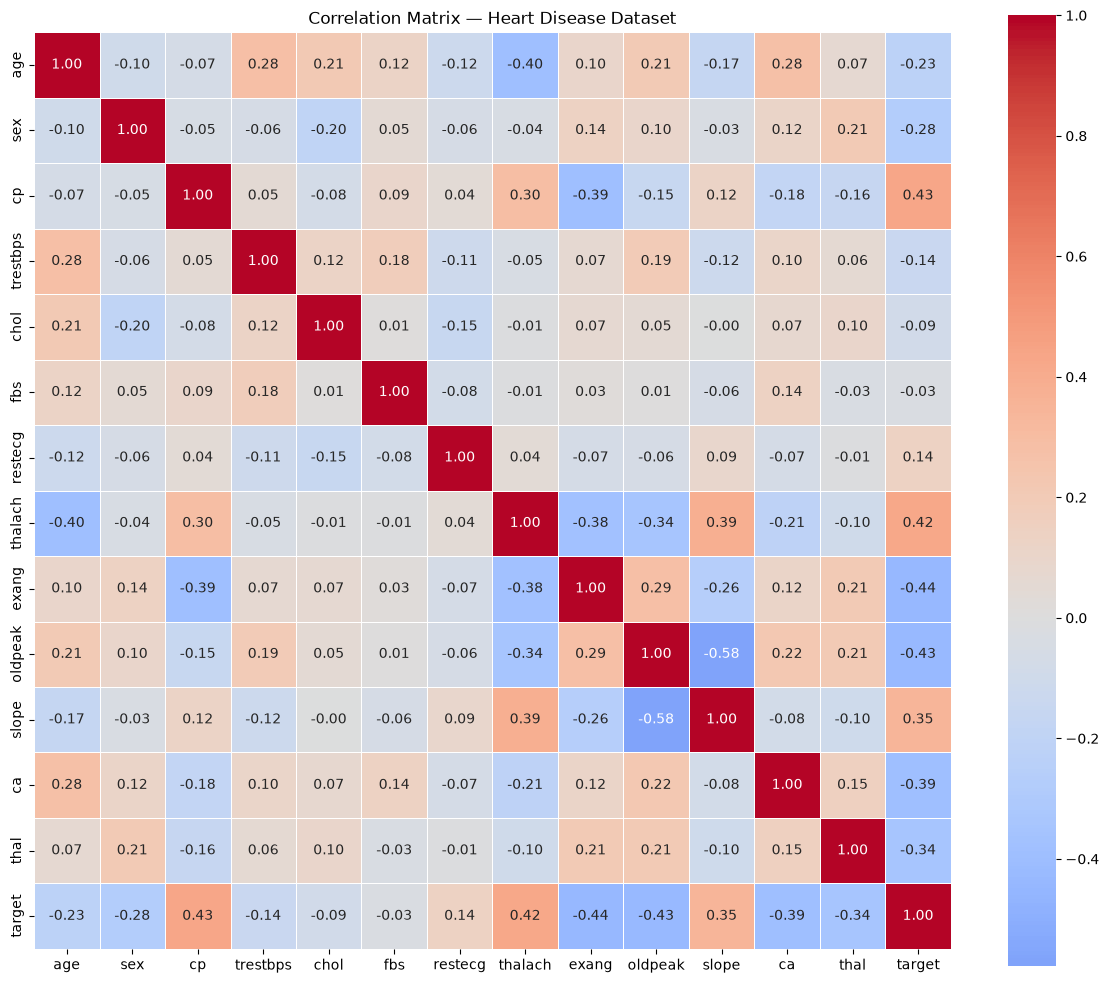

Correlations with target (sorted):
target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64


In [3]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix — Heart Disease Dataset')
plt.tight_layout()
plt.show()

print("Correlations with target (sorted):")
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print(target_corr)

### Data Quality Check — Target Column Correction

While reviewing the correlation results above, several features known to
indicate heart disease clinically (`exang` = exercise-induced angina,
`oldpeak` = ST depression, `ca` = blocked vessels) showed a **negative**
correlation with `target` — the opposite of medical expectation.

Investigation confirmed this is a known, documented issue: the source file
used here mirrors a popular Kaggle upload of the UCI Heart Disease dataset
that has a confirmed bug — the `target` column was inverted during that
upload relative to the original UCI encoding (where 1 = disease present,
0 = no disease). This has been discussed publicly by other users of the same
file, and a "corrected" replacement dataset was later published specifically
to fix it.

**Fix applied:** the `target` column is flipped (0 ↔ 1) so that `target = 1`
correctly means "heart disease present," matching the original UCI standard
and the column's documented meaning.

In [4]:
df['target'] = 1 - df['target']

print("Corrected target distribution:")
print(df['target'].value_counts())

Corrected target distribution:
target
0    165
1    138
Name: count, dtype: int64


In [5]:
correlation_matrix = df.corr()

print("Correlations with target (sorted) — after correction:")
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print(target_corr)


Correlations with target (sorted) — after correction:
target      1.000000
exang       0.436757
oldpeak     0.430696
ca          0.391724
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
chol        0.085239
fbs         0.028046
restecg    -0.137230
slope      -0.345877
thalach    -0.421741
cp         -0.433798
Name: target, dtype: float64


### Section 2 — Results & Interpretation

**Initial EDA:** 303 patients, 14 columns, zero missing values, target
roughly balanced (originally 165/138, corrected to 138 disease-positive /
165 disease-negative after the target-flip fix).

**Correlation with target (post-correction), strongest to weakest:**
- Positive: `exang` (0.44), `oldpeak` (0.43), `ca` (0.39), `thal` (0.34),
  `sex` (0.28), `age` (0.23)
- Negative: `cp` (-0.43), `thalach` (-0.42), `slope` (-0.35)

**Interpretation:** after correcting the target inversion, every strong
correlation now matches established medical knowledge — exercise-induced
angina, ST depression, blocked vessels, thalassemia defects, older age, and
male sex are all recognized heart disease risk factors, and all now
correctly show positive correlation with disease presence. This gives strong
confidence the target correction was necessary and correctly applied before
proceeding to modeling.

## Section 3 — Data Preprocessing

Before training Logistic Regression, we need to prepare the features:

1. **Encode categorical variables** — `cp`, `restecg`, `slope`, and `thal`
   are stored as integer codes but represent categories, not true numeric
   scales (e.g., `cp` = 0,1,2,3 are chest pain *types*, not degrees of
   severity). One-hot encoding avoids the model assuming a false numeric
   order between categories.
2. **Split features and target**
3. **Train/test split**
4. **Scale features** — StandardScaler, fit on training data only, to put
   all features on a comparable scale (important for Logistic Regression,
   which is sensitive to feature magnitude)

In [6]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Shape before encoding: (303, 14)
Shape after encoding: (303, 20)


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,False,False,True,False,False,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,0,False,True,False,True,False,False,False,False,True,False
2,41,0,130,204,0,172,0,1.4,0,0,True,False,False,False,False,False,True,False,True,False
3,56,1,120,236,0,178,0,0.8,0,0,True,False,False,True,False,False,True,False,True,False
4,57,0,120,354,0,163,1,0.6,0,0,False,False,False,True,False,False,True,False,True,False


In [7]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,0,0,1,0,0,0,0,1,0,0
1,37,1,130,250,0,187,0,3.5,0,0,0,1,0,1,0,0,0,0,1,0
2,41,0,130,204,0,172,0,1.4,0,0,1,0,0,0,0,0,1,0,1,0
3,56,1,120,236,0,178,0,0.8,0,0,1,0,0,1,0,0,1,0,1,0
4,57,0,120,354,0,163,1,0.6,0,0,0,0,0,1,0,0,1,0,1,0


In [8]:
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Training set shape: (242, 19)
Test set shape: (61, 19)

Training target distribution:
target
0    132
1    110
Name: count, dtype: int64

Test target distribution:
target
0    33
1    28
Name: count, dtype: int64


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print(f"Training set mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training set std (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete.
Training set mean (should be ~0): -0.0000
Training set std (should be ~1): 1.0000


### Section 3 — Results & Interpretation

**Preprocessing steps completed:**
1. One-hot encoded 4 categorical columns (`cp`, `restecg`, `slope`, `thal`)
   using `drop_first=True` — expanded from 14 to 20 columns, converted to
   clean 0/1 integers
2. Split into features (X) and target (y), then an 80/20 train/test split
   with `stratify=y` to preserve class balance
   - Training: 242 patients (132 negative / 110 positive)
   - Test: 61 patients (33 negative / 28 positive)
   - Both sets closely match the full dataset's ~54.5%/45.5% balance
3. Applied StandardScaler (fit on training data only, then applied to test
   data) — confirmed training set mean ≈ 0, std = 1.0000

Data is now fully prepared for Logistic Regression: no missing values,
categoricals properly encoded, features on a comparable scale, and
target confirmed correctly labeled (1 = disease present) after the
Section 2 correction.

## Section 4 — Model Training

Training a Logistic Regression model on the scaled training data to predict
heart disease presence (`target`).

In [10]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")
print(f"\nNumber of features: {X_train_scaled.shape[1]}")

Model trained successfully.

Number of features: 19


In [11]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8525
Precision: 0.8800
Recall: 0.7857
F1 Score: 0.8302


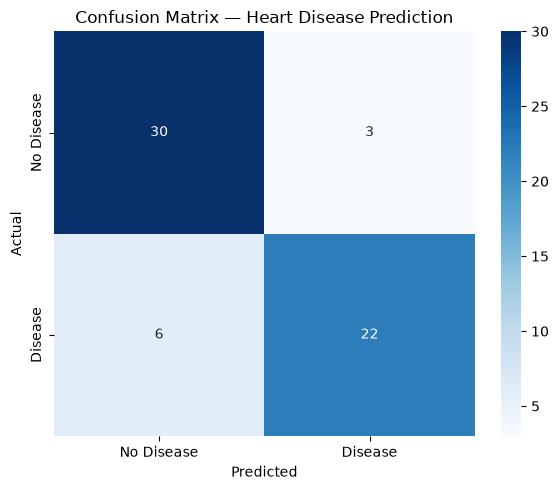

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        33
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Heart Disease Prediction')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

### Section 4 — Results & Interpretation

**Test set performance (61 patients):**
- Accuracy: 85.25%
- Precision: 88.00%
- Recall: 78.57%
- F1 Score: 83.02%

**Confusion Matrix:**
|                  | Predicted: No Disease | Predicted: Disease |
|------------------|------------------------|---------------------|
| **Actual: No Disease** | 30 (True Negative)     | 3 (False Positive)  |
| **Actual: Disease**    | 6 (False Negative)     | 22 (True Positive)  |

**Interpretation:** the model correctly classifies 85% of patients overall.
It is particularly strong at ruling out healthy patients (only 3 false
alarms out of 33 healthy patients, recall 91% for "No Disease"). Its main
weakness is 6 missed disease cases out of 28 actual disease patients
(recall 78.57% for "Disease") — these represent patients who have heart
disease but were predicted healthy. In a real clinical context, this type
of error (false negative) is generally more costly than a false alarm,
since a missed diagnosis could delay necessary treatment. This is a
genuine limitation of the model as currently built and worth flagging
rather than glossing over, even though overall performance is solid.